# Classification d'images à l'aide d'algorithmes de Deep Learning

Projet n&#8239;$^\text{o}$ 6 du [cursus Machine Learning Engineer][2] d'OpenClassrooms

Auteur : [Kiril ISAKOV][1]

Mentor : Nicolas TISSERAND

Projet démarré le 23/03/2026

[1]: https://github.com/kirisakow/
[2]: https://openclassrooms.com/fr/paths/794-machine-learning-engineer

# Notebook de création et d’entraînement du modèle par *transfer learning*

## Imports et constantes

In [ ]:
DEFAULT_TRGT_IMG_SIZE = (224, 224)
DEFAULT_BATCH_SIZE = 32

import os
# Déclarer le backend avant d'importer keras (sinon par défaut c'est 'tensorflow'):
os.environ["KERAS_BACKEND"] = "torch"
# Memory optimization: Enable expandable segments to reduce fragmentation:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# Limiter la verbosité des logs de tensorflow:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from functions_model_building import (
    build_model_from_pretrained,
    MyKerasSequence,
    plot_accuracy_and_loss_values,
    plot_confusion_matrix,
)
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import keras
from keras import layers
from keras.applications.efficientnet import EfficientNetB0
from keras.applications.efficientnet_v2 import EfficientNetV2B0
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image_dataset_from_directory
# Memory optimization: Use mixed precision (if GPU supports it):
keras.mixed_precision.set_global_policy('mixed_float16')

from collections import Counter
from lxml import etree
from pathlib import Path
from PIL import Image
from pprint import pprint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import cv2
import datetime as dt
import joblib
import itertools as it
import matplotlib.pyplot as plt
import numpy as np
import pytz
import seaborn as sns
sns.set()

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")

LOGGER_FORMAT = '%(asctime)s [%(levelname)s] %(message)s'
logging.Formatter.converter = lambda *_: dt.datetime.now(pytz.timezone('Europe/Paris')).timetuple()
logging.basicConfig(level=logging.INFO, format=LOGGER_FORMAT, force=True)
logr = logging.getLogger(__name__)
logr.setLevel(logging.DEBUG)
# log_file_handler = logging.FileHandler(f"log/{dt.datetime.isoformat(dt.datetime.now(pytz.timezone('Europe/Paris'))).split('.')[0]}.log")
# log_file_handler.setLevel(logging.DEBUG)
# log_cons_handler = logging.StreamHandler()
# log_cons_handler.setLevel(logging.DEBUG)
# log_file_handler.setFormatter(logging.Formatter(fmt=LOGGER_FORMAT, style='%'))
# log_cons_handler.setFormatter(logging.Formatter(fmt=LOGGER_FORMAT, style='%'))
# logr.addHandler(log_file_handler)
# logr.addHandler(log_cons_handler)


## Étapes préliminaires : installer les pilotes GPU et tester l'installation

1. Installer ou mettre à jour le pilote pour la GPU. Par ici pour les GPU Nvidia : https://www.nvidia.com/en-us/drivers/ (spécifier le bon modèle dans le formulaire)

2. Installer le dernier CUDA toolkit (v13.2) de chez Nvidia : 

   - soit de la façon [`runfile (local)`][2] :

     ```bash
     # télécharger l'archive (taille approximative : 4,1 Go)
     wget https://developer.download.nvidia.com/compute/cuda/13.2.0/local_installers/cuda_13.2.0_595.45.04_linux.run

     # exécuter l'archive
     sudo sh cuda_13.2.0_595.45.04_linux.run
     ```

   - soit de la façon [`deb (network)`][3] :

     ```bash
     wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/cuda-keyring_1.1-1_all.deb
     
     sudo dpkg -i cuda-keyring_1.1-1_all.deb
     
     sudo apt update
     
     sudo apt -y install cuda-toolkit-13-2
     ```

3. Ajouter les chemins suivants aux variables d'environnement PATH et LD_LIBRARY_PATH :

     ```bash
     echo 'export PATH=/usr/local/cuda/bin:$PATH' >> ~/.bashrc
     echo 'export LD_LIBRARY_PATH=/usr/local/cuda/lib64:/usr/lib/x86_64-linux-gnu:$LD_LIBRARY_PATH' >> ~/.bashrc

     # Enfin, recharger .bashrc
     source ~/.bashrc
     ```

4. Installer le backend pour Keras (PyTorch, TensorFlow ou JAX) :

   - Pour PyTorch : Suivre [les instructions de la doc PyTorch][1] : Installer le backend `torch` and `torchvision` compatibles CUDA `>=13.0` pour les GPU Nvidia (ou ROCm `>=7.2` pour les GPU AMD).

   - Si besoin, spécifier dans `pyproject.toml` des bornes plus strictes à la version de Python : par exemple, non pas `>=3.12` mais `>=3.12,<3.14`.

5. Installer Keras : Suivre [les instructions de la doc Keras][4]

[1]: https://pytorch.org/get-started/locally/
[2]: https://developer.nvidia.com/cuda-downloads?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=24.04&target_type=runfile_local
[3]: https://developer.nvidia.com/cuda-downloads?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=24.04&target_type=deb_network
[4]: https://keras.io/getting_started/

### Tester l'installation de CUDA toolkit et de PyTorch

In [2]:
logr.debug(f"PyTorch version: {torch.__version__}")
logr.debug(f"Is CUDA available: {torch.cuda.is_available()}")
logr.debug(f"CUDA device count: {torch.cuda.device_count()}")
logr.debug(f"Current device: {torch.cuda.current_device()}")
logr.debug(f"Device name: {torch.cuda.get_device_name(0)}")

2026-05-07 12:23:41,571 [DEBUG] PyTorch version: 2.11.0+cu130
2026-05-07 12:23:41,615 [DEBUG] Is CUDA available: True
2026-05-07 12:23:41,634 [DEBUG] CUDA device count: 1
2026-05-07 12:23:41,635 [DEBUG] Current device: 0
2026-05-07 12:23:41,636 [DEBUG] Device name: NVIDIA GeForce RTX 2070 with Max-Q Design


## Entraînement du modèle de prédiction par *transfer learning*

### 1. Modèle à 3 classes et ses différentes variantes

#### 1.0. Split train - val - test (à lancer avant chaque entraînement)

In [2]:
input_img_paths = tuple([
    Path('images/n02090379-redbone'), Path('images/n02085936-Maltese_dog'), Path('images/n02088094-Afghan_hound')
])
logr.info(f"Les classes retenues : {input_img_paths}")
input_img_paths = tuple(path.glob('*.jpg') for path in input_img_paths)
input_img_paths = tuple(it.chain.from_iterable(input_img_paths))
logr.info(f"Résultat : un tuple de {len(input_img_paths)} images pour les 3 classes de races.")
breed_labels = tuple(str(path).split('/')[1] for path in input_img_paths)
breed_labels_encoded = LabelEncoder().fit_transform(breed_labels)
breed_labels_dict = dict(sorted(zip(breed_labels_encoded, breed_labels)))
logr.info(f"Distribution des classes : {dict(Counter(breed_labels))}")
display(dict(Counter(breed_labels)))
train_frac = 0.8
input_paths_train, input_paths_val_test, labels_train, labels_val_test = train_test_split(
    input_img_paths, breed_labels, train_size=train_frac,
    random_state=42, shuffle=True, stratify=breed_labels,
)
val_test_frac = 0.5
input_paths_val, input_paths_test, labels_val, labels_test = train_test_split(
    input_paths_val_test, labels_val_test, train_size=val_test_frac,
    random_state=42, shuffle=True, stratify=labels_val_test
)
del input_paths_val_test, labels_val_test
logr.info(f"Train size ({train_frac}): {len(input_paths_train)}")
logr.info(f"Val size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_val)}")
logr.info(f"Test size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_test)}")

2026-05-12 01:52:22,609 [INFO] Les classes retenues : (PosixPath('images/n02090379-redbone'), PosixPath('images/n02085936-Maltese_dog'), PosixPath('images/n02088094-Afghan_hound'))
2026-05-12 01:52:22,627 [INFO] Résultat : un tuple de 639 images pour les 3 classes de races.
2026-05-12 01:52:22,630 [INFO] Distribution des classes : {'n02090379-redbone': 148, 'n02085936-Maltese_dog': 252, 'n02088094-Afghan_hound': 239}


{'n02090379-redbone': 148,
 'n02085936-Maltese_dog': 252,
 'n02088094-Afghan_hound': 239}

2026-05-12 01:52:22,639 [INFO] Train size (0.8): 511
2026-05-12 01:52:22,640 [INFO] Val size (0.1): 64
2026-05-12 01:52:22,640 [INFO] Test size (0.1): 64


#### 1.a) Entraînement à 3 classes sur la base du modèle pré-entraîné `EfficientNetB0`

In [ ]:
PRTR_MDL = EfficientNetB0
PREPROCESSING_FUNC = keras.applications.efficientnet.preprocess_input
train_seq = MyKerasSequence(input_paths_train, labels_train, batch_size=DEFAULT_BATCH_SIZE, target_size=DEFAULT_TRGT_IMG_SIZE, preprocessing_func=PREPROCESSING_FUNC)
val_seq = MyKerasSequence(input_paths_val, labels_val, batch_size=DEFAULT_BATCH_SIZE, target_size=DEFAULT_TRGT_IMG_SIZE, preprocessing_func=PREPROCESSING_FUNC)
test_seq = MyKerasSequence(input_paths_test, labels_test, batch_size=DEFAULT_BATCH_SIZE, target_size=DEFAULT_TRGT_IMG_SIZE, preprocessing_func=PREPROCESSING_FUNC)
N_CLASSES = 3
N_EPOCHS = 20
DROPOUT_RATE = 0.2
LR = 1e-5  # learning rate doit être faible !
experiment_name = f'CNN__from={PRTR_MDL.__name__}__n_cls={N_CLASSES}__n_eps={N_EPOCHS}__drpt={DROPOUT_RATE:.2f}__LR={LR}'

Construire le modèle :

In [5]:
model = build_model_from_pretrained(
    pretrained_model=PRTR_MDL,
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    dropout_rate=DROPOUT_RATE,
    experiment_name=experiment_name
)
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    # model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Entraînement et validation :

In [6]:
torch.cuda.empty_cache()

2026-05-12 01:59:56,279 [INFO] Désérialiser l'objet sauvegardé 'CNN__from=EfficientNetB0__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05_model.keras'
2026-05-12 01:59:57,307 [INFO] Désérialiser l'objet sauvegardé 'CNN__from=EfficientNetB0__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05_history.joblib'


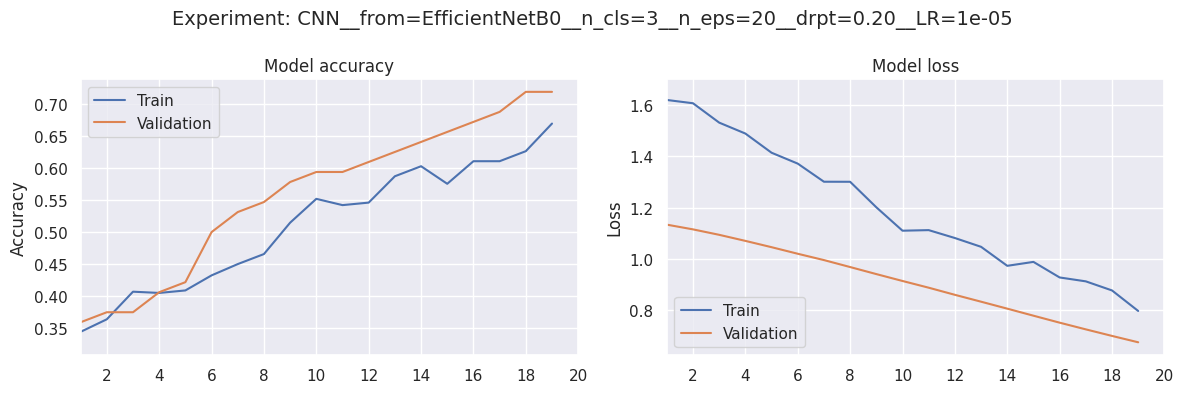

2026-05-12 01:59:58,400 [INFO] Précision finale de l'entraînement: 0.6693
2026-05-12 01:59:58,400 [INFO] Précision finale de la validation: 0.7188
2026-05-12 01:59:58,401 [INFO] Loss finale de l'entraînement: 0.7975
2026-05-12 01:59:58,402 [INFO] Loss finale de la validation: 0.6755


In [ ]:
path_to_model = f'models/from_pretrained/{experiment_name}_model.keras'
path_to_history = f'models/from_pretrained/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location={'accuracy': 'upper left', 'loss': 'lower left'})
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

2026-05-12 01:55:54,808 [INFO] Évaluation sur les données de test :


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.7344 - loss: 0.7664


2026-05-12 01:55:55,369 [INFO] loss, accuracy = [0.7664028406143188, 0.734375]


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


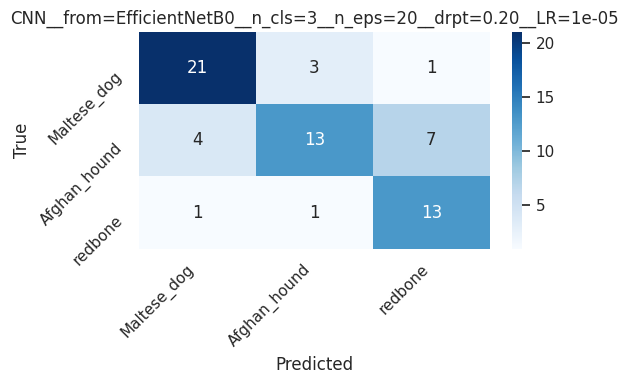

In [9]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")
plot_confusion_matrix(model, test_seq, test_seq.yset, breed_labels_dict.values(), title=f'{experiment_name}')

#### 1.b) Entraînement à 3 classes sur la base du modèle pré-entraîné `EfficientNetV2B0`

#### 1.c) Entraînement à 3 classes sur la base du modèle pré-entraîné `VGG16`